In [1]:
#7 判别分析算法
#7.1  载入分析所需要的模块和函数
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA

In [ ]:
#7.2  数据读取及观察
data=pd.read_csv('数据6.1.csv').drop(['V5'],axis=1) #读取数据，并删除无用变量V5
print(data.info())
print(len(data.columns))
print(data.columns)
print(data.shape)
print(data.dtypes)
print(data.isnull().values.any()) #检查是否有缺失值
print(data.isnull().sum()) #统计每一列缺失值的数量
print(data.head())#显示前5行数据
print(data.V1.value_counts())#显示响应变量V1的各类别频数


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1034 entries, 0 to 1033
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      1034 non-null   int64  
 1   V2      1034 non-null   int64  
 2   V3      1034 non-null   float64
 3   V4      1034 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 32.4 KB
None
4
Index(['V1', 'V2', 'V3', 'V4'], dtype='object')
(1034, 4)
V1      int64
V2      int64
V3    float64
V4    float64
dtype: object
False
V1    0
V2    0
V3    0
V4    0
dtype: int64
   V1  V2     V3     V4
0   3   2  110.9  107.0
1   3   5   73.8   73.5
2   3   2  111.3  101.9
3   3   4  247.7  202.0
4   3   8  227.5  167.0
V1
2    417
3    407
1    210
Name: count, dtype: int64


<Axes: >

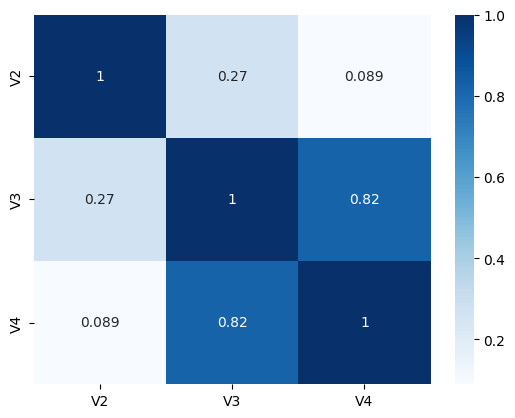

In [4]:
#7.3  特征变量相关性分析
X = data.drop(['V1'],axis=1)#设置特征变量，即除V1之外的全部变量
y = data['V1']#设置响应变量，即V1
X.corr() #计算特征变量之间的相关系数矩阵
sns.heatmap(X.corr(), cmap='Blues', annot=True) #绘制特征变量之间的相关系数热力图

        LD1       LD2  收入档次
0  3.579521 -0.341713     3
1  2.820259 -1.002730     3
2  3.546140 -0.239229     3
3  2.782573  1.936977     3
4  1.647307  1.754220     3


<Axes: xlabel='LD1', ylabel='LD2'>

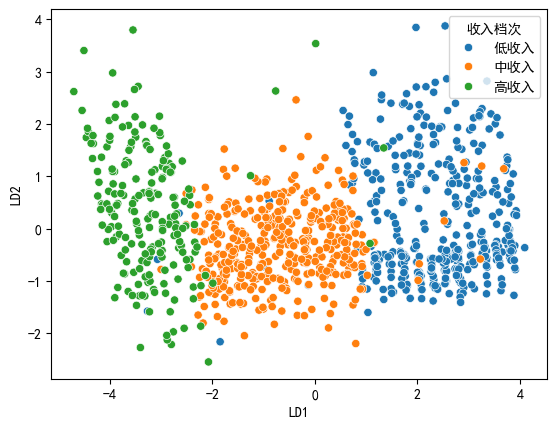

In [7]:
#7.4  使用样本示例全集开展线性判别分析
#7.4.1  模型估计及性能分析
# 使用样本示例全集开展LDA
model = LinearDiscriminantAnalysis()#使用LDA算法
model.fit(X, y)#使用fit方法进行拟合
model.score(X, y)#计算模型预测的准确率

np.set_printoptions(suppress=True)#不以科学计数法显示，而是直接显示数字

lda_scores = model.fit(X, y).transform(X) #使用fit方法进行拟合，并使用transform方法进行降维

LDA_scores = pd.DataFrame(lda_scores, columns=['LD1', 'LD2'])
LDA_scores['收入档次'] = data['V1']
print(LDA_scores.head())  

d = {1: '高收入', 2: '中收入', 3: '低收入'}
LDA_scores['收入档次'] = LDA_scores['收入档次'].map(d) 
LDA_scores.head()
plt.rcParams['axes.unicode_minus']=False# 解决图表中负号不显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']#解决图表中中文显示问题。
sns.scatterplot(x='LD1', y='LD2', data=LDA_scores, hue='收入档次')


/Users/longmozhou/Documents/文稿 - LongMacBook Pro/深度学习/cs336/assignment1-basics/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'LDA决策边界')

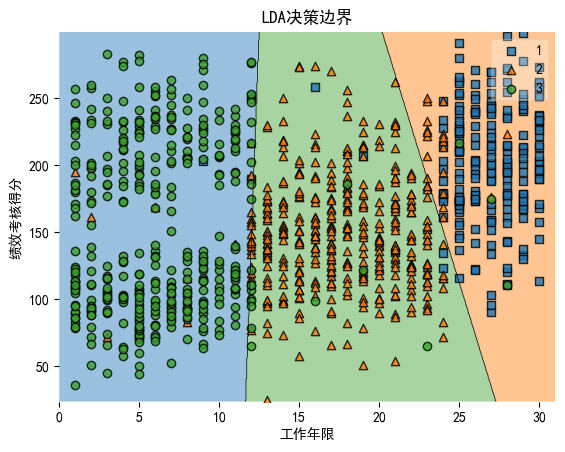

In [8]:
#7.4.2  运用两个特征变量绘制LDA决策边界图
from mlxtend.plotting import plot_decision_regions#导入plot_decision_regions


X2 = X.iloc[:,0:2]#仅选取V2工作年限、V3绩效考核得分作为特征变量
model = LinearDiscriminantAnalysis()#使用LDA算法
model.fit(X2, y)#使用fit方法进行拟合
model.score(X2, y)
model.explained_variance_ratio_

plot_decision_regions(np.array(X2), np.array(y), model)
plt.xlabel('工作年限')
plt.ylabel('绩效考核得分')
plt.title('LDA决策边界')#将标题设置为'LDA决策边界'

In [ ]:
#7.5  使用分割样本开展线性判别分析
X_train, X_test, y_train, y_test =  train_test_split(X,y,test_size=0.3, stratify=y, random_state=123)
model = LinearDiscriminantAnalysis()#使用LDA算法
model.fit(X_train, y_train)#基于训练样本使用fit方法进行拟合
model.score(X_test, y_test)#基于测试样本计算模型预测的准确率

prob = model.predict_proba(X_test)

pred = model.predict(X_test)

print(confusion_matrix(y_test, pred))#输出测试样本的混淆矩阵

print(classification_report(y_test, pred))

cohen_kappa_score(y_test, pred) #计算Kappa系数

[[ 60   2   1]
 [  0 121   5]
 [  0   0 122]]
              precision    recall  f1-score   support

           1       1.00      0.95      0.98        63
           2       0.98      0.96      0.97       126
           3       0.95      1.00      0.98       122

    accuracy                           0.97       311
   macro avg       0.98      0.97      0.97       311
weighted avg       0.98      0.97      0.97       311



0.9597586814822003